In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from define_data_and_variables import hmc_config, data
import os
from matplotlib import colors

In [2]:
base_path = "../../../../data/"
output_dir = os.path.join(base_path, data["dn"])

In [3]:
cutout = 1000
energy_values = np.load(f"{output_dir}/energy.npy")[:, cutout:]
samples = np.load(f"{output_dir}/samples.npy")[:, cutout:]

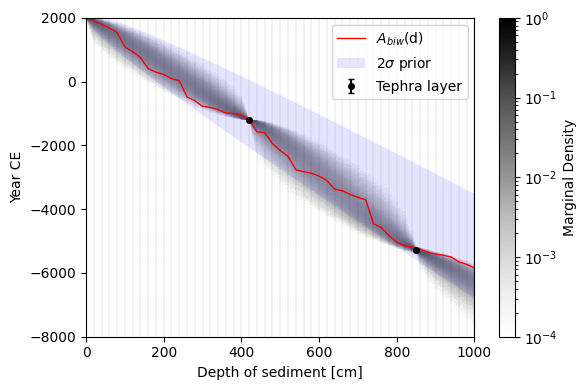

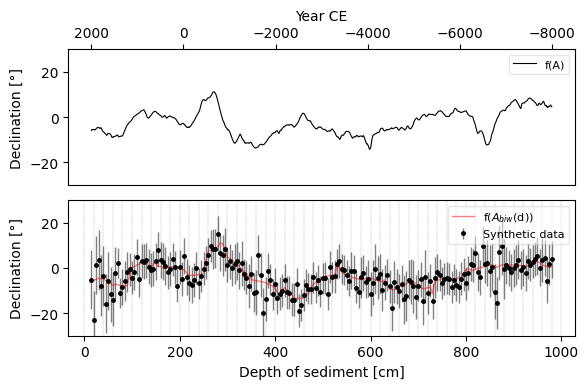

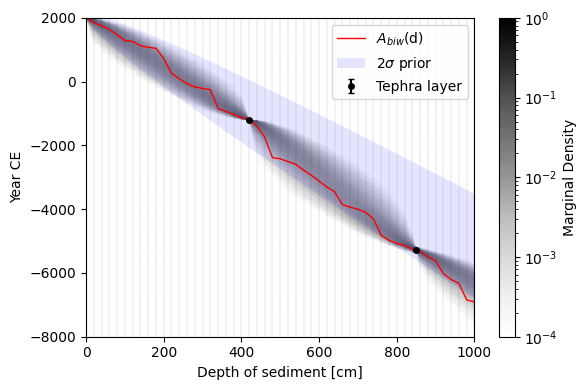

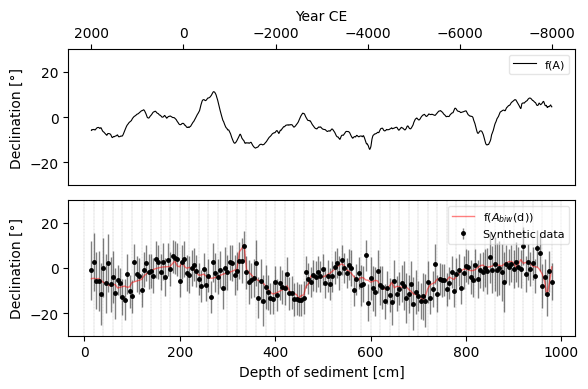

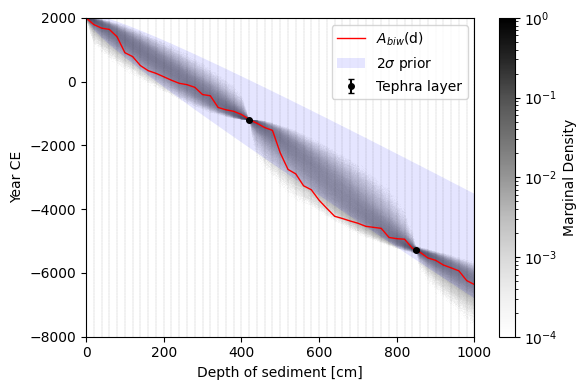

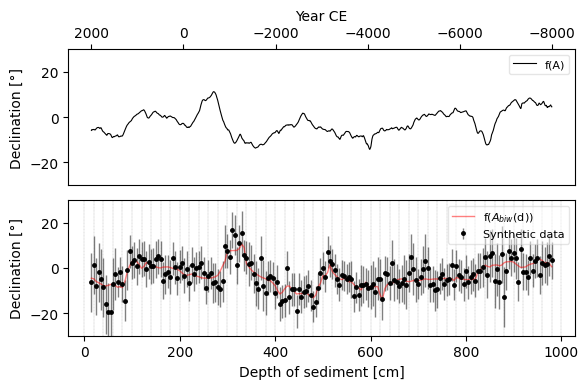

In [4]:
# Labels
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"Tephra layer"
d18o_label = "$\\delta^{18}$O [‰]" if "d18o" in data["dn"] else "inc [°]" if "inc" in data["dn"] else "dec [°]"

# Computing histograms of all samples for plotting
chain = 4
X = samples[chain].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if np.max(data["d18ort"]) - np.min(data["d18ort"]) < 2000 else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = data["H"] / 1000
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for j in range(Z):
    C[j, :], _ = np.histogram(A[j, :], bins=t_edges, density = True)

C /= (np.sum(C, axis=1, keepdims=True) + 1e-12)
C[C<=0] = np.nan

# Prior mean and std for plotting
prior_mean = data["th"] - data["cs"] * np.exp(data["pm"] + (data["ps"]**2 / 2))
prior_2_std = 2 * np.sqrt(data["cs"] * data["dc"] * (np.exp(data["ps"]**2)-1) * np.exp(2*data["pm"] + data["ps"]**2))

rng = np.random.default_rng(seed=hmc_config["sd"])
model_ages_list = []
cutout = 1000
samples = samples[:, cutout:, :]
flat_samples = samples.reshape(-1, samples.shape[-1])

for i in range(3):
    random_idx = rng.integers(0, flat_samples.shape[0])

    sample = np.load(f"{output_dir}/{i}/true_sample.npy")

    cumulative_sums = np.cumsum(sample) * data["dc"]
    zeros = np.zeros((*sample.shape[:1], 1))
    age_offset = np.concatenate((np.array([0]), cumulative_sums))
    model_age = data["th"] - age_offset
    model_ages_list.append(model_age)

    depths_interp = np.interp(data["d18ort"], model_age[::-1], data["cs"][::-1], right = np.nan, left = np.nan)[::-1]
    d18O_actual_nr = np.interp(data["d18od"], depths_interp, data["d18or"][::-1], right = np.nan, left = np.nan)
    d18O_actual = d18O_actual_nr + rng.normal(loc=0, scale=data["d18os"], size=len(data["d18od"]))
    years_actual = np.interp(data["d18od"], data["cs"], model_age, right = np.nan, left = np.nan)
    years_c14_actual = np.interp(data["c14d"],data["cs"], model_age, right = np.nan, left = np.nan)

    init_nan = np.full(1, np.nan)
    init_nans_c14 = np.full(1 + len(data["c14d"]), np.nan)
    extra_nans = np.full(len(data["d18od"]), np.nan)

    depths = np.concatenate((np.array([0]), data["c14d"], data["d18od"]))
    true_ages = np.concatenate((np.array([data["th"]]), years_c14_actual, years_actual))
    cal_c14_ages = np.concatenate((init_nan, data["c14"], extra_nans))
    sigma_age = np.concatenate((init_nan, data["c14s"], extra_nans))
    d18O = np.concatenate((init_nans_c14, d18O_actual))
    sigma_d18O = np.concatenate((init_nans_c14, data["d18os"]))

    # df = pd.DataFrame({
    #     "depth": depths,
    #     "true_age": true_ages,
    #     "age": cal_c14_ages,
    #     "sigma_age": sigma_age,
    #     "ref": d18O,
    #     "sigma_ref": sigma_d18O
    # }) 

    # file_path = Path(output_dir) / f"{i}" / "data.txt"
    # file_path.parent.mkdir(parents=True, exist_ok=True)
    # df.to_csv(file_path, sep="\t", index=False)

    # --------Plotting generated age-depth model and samples----------
    fig, ax = plt.subplots(figsize=(6, 4))
    plt.set_cmap(plt.cm.Greys)

    # samples
    im = ax.pcolormesh(z, t, C.T, norm=colors.LogNorm(1e-4, 1))

    cbar = plt.colorbar(im)
    cbar.set_label("Marginal Density")

    ad_label = rf"$A_{{{data['dn'][:3]}{'e' if 'edit' in data['dn'] else ''}}}$(d)"
    # generated sample
    ax.plot(
        data["cs"],
        model_age,
        color="red",
        alpha=1,
        linewidth=1,
        label = ad_label,
    )

    for j, c in enumerate(data["cs"]):
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
    
    # prior
    plt.fill_between(
        data["cs"], 
        prior_mean - prior_2_std, 
        prior_mean + prior_2_std, 
        color="blue", 
        alpha=0.1,
        linewidth=0,
        label=r"2$\sigma$ prior"
    )
    ax.set_xlim(0, np.max(data["cs"]))
    if "d18o" in data["dn"]:
        ax.set_ylim(1200, 2000)
        plt.xlabel("Distance from top of stalagmite [mm]")
    else:
        ax.set_ylim(-8000, 2000)
        plt.xlabel("Depth of sediment [cm]")

    # direct dates
    plt.errorbar(data["c14d"], data["c14"], yerr = data["c14s"], fmt ="o", color = 'k', capsize = 2, markersize=4, label = c14_label)
    plt.ylabel("Year CE")
    plt.legend(loc = "upper right")
    plt.tight_layout()
    # plt.savefig(f"{output_dir}/{i}/ad_sample.jpg", dpi=300, bbox_inches="tight")
    plt.show()

    # ---------Plotting generated data and reference function-----------
    fig, (ax3, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=False)

    valid_mask = ~np.isnan(d18O)

    ax2.errorbar(
        depths[valid_mask],
        d18O[valid_mask], 
        yerr=2 * sigma_d18O[valid_mask],
        fmt='.', 
        markersize=5,
        capsize=4, 
        elinewidth=1, 
        capthick=0,
        color="black",
        ecolor='gray', 
        alpha=1,
        label="Synthetic data"
    )

    ax2.plot(data["d18od"], d18O_actual_nr, color = "red", alpha = 0.5, linewidth = 1, label = f"f({ad_label})")

    if "biw" in data["dn"]:
        ax2.set_xlabel("Depth of sediment [cm]") 
        ax2.set_ylabel(r"Declination [°]")
        ax3.set_ylabel(r"Declination [°]")
        ax2.set_ylim(-30, 30)
        ax3.set_ylim(-30, 30)
    elif "d18o" in data["dn"]:
        ax2.set_xlabel("Distance from top of stalagmite [mm]") 
        ax2.set_ylabel("$\\delta^{18}$O [‰]")
        ax3.set_ylabel("$\\delta^{18}$O [‰]")
        if "dayu" in data["dn"]:
            ax2.set_ylim(-9.5, -7.5)
            ax3.set_ylim(-9.5, -7.5)
        else:
            ax2.set_ylim(-8, -6)
            ax3.set_ylim(-8, -6)

    # Discretization
    for d in data["cs"]:
        ax2.axvline(x=d, color='k', linestyle='--', linewidth=0.2, alpha=0.5)

    # data
    ax3.plot(data["d18ort"], data["d18or"], color="k", linewidth=0.8, label = "f(A)")
    ax3.set_xlabel("Year CE")
    ax3.invert_xaxis()
    ax3.xaxis.tick_top()
    ax3.xaxis.set_label_position('top')
    ax2.legend(framealpha = 0.5, loc = "upper right", fontsize=8)
    ax3.legend(framealpha = 0.5, loc = "upper right", fontsize=8)
    plt.tight_layout()
    # plt.savefig(f"{output_dir}/{i}/data_fig.jpg", dpi=300, bbox_inches="tight")
    plt.show()


In [5]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [6]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd    ess_bulk  ess_tail  \
x[0]   7.60  5.78    0.74    17.95       0.02     0.06   541429.98  29804.21   
x[1]   7.56  5.68    0.78    17.77       0.02     0.06   533798.78  28701.32   
x[2]   7.62  5.80    0.69    18.09       0.02     0.06   516696.54  31701.46   
x[3]   7.67  5.91    0.69    18.37       0.02     0.06   533675.16  27901.69   
x[4]   7.64  5.86    0.70    18.24       0.02     0.06   508338.82  29398.91   
x[5]   7.60  5.77    0.68    17.98       0.02     0.06   496038.57  29748.71   
x[6]   7.60  5.80    0.72    18.00       0.02     0.06   520196.24  28953.84   
x[7]   7.61  5.82    0.71    18.09       0.02     0.06   537418.27  29496.42   
x[8]   7.60  5.77    0.73    18.12       0.02     0.06   497821.96  30048.80   
x[9]   7.63  5.85    0.71    18.20       0.02     0.06   529746.38  27928.52   
x[10]  7.63  5.86    0.68    18.13       0.02     0.06   535815.11  28729.61   
x[11]  7.65  5.92    0.69    18.20      

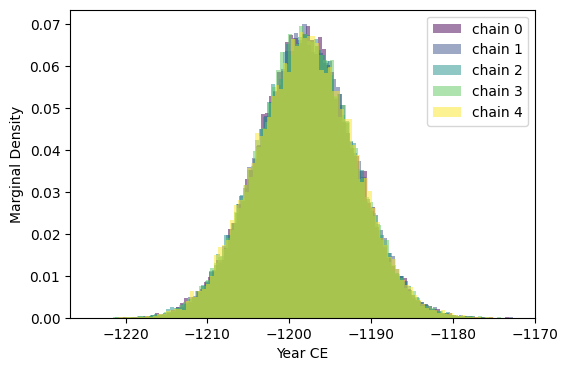

In [7]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))
index = 21
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(samples[:, 5000:, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.xlabel("Year CE")
plt.ylabel("Marginal Density")
plt.legend()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

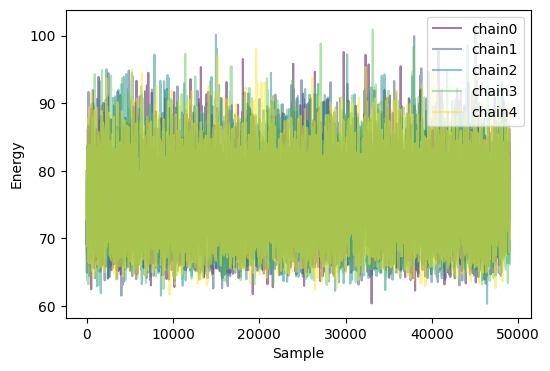

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.plot(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Energy")
# plt.savefig(f"{output_dir}/energy_evol.jpg")
plt.show()   